# v2_sweepA 오분류(FP/FN) 구조 진단 EDA

확정 모델 **`v2_sweepA`** (test PR-AUC 0.608 · 유사상품 위주 11관계 · HINGNNv2)에서 **왜 성공을 실패로(FN), 실패를 성공으로(FP) 예측했는가**를 그래프 구조(노드·엣지·이웃 패턴)에서 규명. TP/TN 대조 4분면 비교.

- 범위: **test-only**(754) · 임계값 **val F1-max = 0.5593** 고정
- 누수 차단: 고성공/고실패 키워드 장부·이웃 성공률은 **train+val 라벨로만** 산출
- 메커니즘 가설: 점수 지배 관계(α_r) = **유사키워드(sim_kw) ≫ 유사IP(sim_ip) ≫ 기타** → 1순위 원인 = 유사상품 관계 **이웃의 라벨 구성**
- 모델: v2는 **leak-free** — 이전 exp41이 의존한 동반구매(`co_offline`, α0.13)가 *출시-후 매출 누수*라 제거하고 `basket_comp`(키워드)·보조 예측 타깃으로 재배치(`docs/final_model_leakfree_switch_plan.md`)
- 예측값: 공식 `serve.py`도 export 산출물로 서빙(torch 불필요) — 본 분석도 동일하게 저장된 `learned_product_scores` 사용(HINGNNv2 직접추론과 test PR-AUC 0.608 동일 재현)

## 📌 실행 요약 (분석 지도)
**왜**: 확정 모델 v2_sweepA(test PR-AUC 0.608 = 랜덤 0.239의 **2.55배**)이 *어디서·왜* 틀리는지 구조로 설명.
**무엇을**: test 754개를 **TP/FP/FN/TN 4분면**으로 나눠 노드·엣지·이웃 패턴 대조.
**어떻게**: 점수 지배 관계(α_r=유사상품 sim_kw·sim_ip)를 따라 *이웃의 라벨 구성*을 1순위로 진단(이웃 라벨은 train+val만 → 누수 차단).

**3대 결론**
1. 🔴 **FN(놓친 성공, 43개)** = 유사상품(IP) 이웃 성공률 낮음(0.22 vs TP 0.60) → 닮은 성공작이 없는 신규 성공이라 끌어올릴 신호 부재.
2. 🟠 **FP(낚인 실패, 143개)** = 유사상품(IP) 이웃 성공 편중(0.53 ≈ TP 0.60) + 트렌드 키워드 → 성공작과 닮은 외형/IP로 과대.
3. 🟡 **채널** = 세븐 과대예측(정밀도 0.49) / CU 비교적 균형(0.69) / GS25 과대예측 최악(0.25).

> 각 모듈은 **🎯 목표 → 📊 핵심 그림 → ✅ 결론** 순. 상세 표는 그림 아래. Run All 시 `report_assets/*.png` + `network_eda_report.md` 자동 생성.
> v2는 동반구매(co_offline/co_quick)를 **미사용** — 모든 신호가 채널 독립이라 채널 전용 전제가 없다.

In [1]:
# [M0-a] 환경·경로
import sys, json, warnings, yaml
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
ROOT=Path.cwd()
while not (ROOT/'src'/'models'/'hin_gnn.py').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
sys.path.insert(0,str(ROOT)); print('ROOT=',ROOT)
SHARE_HIN=ROOT/'7eleven_npd_share'/'data'/'processed'/'hin'
SHARE_PROC=ROOT/'7eleven_npd_share'/'data'/'processed'
EXP_DIR=ROOT/'experiments'/'results'/'v2_sweepA'
NB_DIR=ROOT/'eda'/'network_eda_원준'; ASSETS=NB_DIR/'report_assets'; ASSETS.mkdir(parents=True,exist_ok=True)
CFG=yaml.safe_load(open(EXP_DIR/'config_used.yaml',encoding='utf-8'))
import matplotlib.pyplot as plt
try: plt.rcParams['font.family']='Malgun Gothic'
except Exception: pass
plt.rcParams['axes.unicode_minus']=False
QORDER=['TP','FP','FN','TN']; QCOLOR={'TP':'#2e7d32','FP':'#c62828','FN':'#1565c0','TN':'#9e9e9e'}
def savefig(fig,name): fig.savefig(ASSETS/name,dpi=120,bbox_inches='tight');
print('edge_types=',len(CFG['graph']['edge_types']),'| ASSETS=',ASSETS)

ROOT= C:\Users\alexj\2026_캡스톤_디자인\세븐일레븐_프로젝트\세븐일레븐_분석_B팀


edge_types= 11 | ASSETS= C:\Users\alexj\2026_캡스톤_디자인\세븐일레븐_프로젝트\세븐일레븐_분석_B팀\eda\network_eda_원준\report_assets


In [2]:
# [M0-b] 그래프 빌드 (exp41 플래그, share 데이터)
from src.data_builder.build_hetero_data import build_graph, forward_edge_index_dict, forward_edge_attr_dict, norm_id
g=CFG['graph']
data,maps=build_graph(data_dir=str(SHARE_HIN),ratios=tuple(CFG['split']['ratios']),seed=CFG['split']['seed'],
  include_offline_copurchase=g.get('include_offline_copurchase',False),
  offline_copurchase_path=str(SHARE_PROC/'offline_commerce_edge_lift_pair_out.csv'),
  include_quick_copurchase=g.get('include_quick_copurchase',False),
  quick_copurchase_path=str(SHARE_PROC/'quick_commerce_edge_lift_pair_out.csv'),
  lift_norm=g.get('lift_normalization','log1p'),use_lift_weights=g.get('use_lift_weights',False),
  use_idf_keyword_weights=g.get('use_idf_keyword_weights',False),
  add_2hop_edges=g.get('add_2hop_edges',False),hop2_kw_min_shared=g.get('hop2_kw_min_shared',5),hop2_ip_min_shared=g.get('hop2_ip_min_shared',2),
  add_via_ip_edges=g.get('add_via_ip_edges',False),add_ipip_kw_edges=g.get('add_ipip_kw_edges',False),add_trend_kw_edges=g.get('add_trend_kw_edges',False))
print('nodes:',{nt:data[nt].num_nodes for nt in ['product','keyword','ip']},'| forward 관계:',len(forward_edge_index_dict(data)))

nodes: {'product': 5033, 'keyword': 2063, 'ip': 335} | forward 관계: 10


In [3]:
# [M0-c] 예측값 로드 — 공식 serve.py와 동일하게 export 산출물(저장 예측 learned_product_scores)로 분석 (HINGNNv2 직접추론과 동일 재현; torch forward 불필요)
import torch
from src.eval.success_predictor import compute_metrics
y_np=data['product'].y.cpu().numpy().astype(int)
tr=data['product'].train_mask.cpu().numpy(); va=data['product'].val_mask.cpu().numpy(); te=data['product'].test_mask.cpu().numpy(); tv=tr|va
al=np.ones(len(y_np),dtype=bool)  # 전체(train+val+test) 분석 마스크
_sc=pd.read_parquet(EXP_DIR/'learned_product_scores.parquet'); _sc['cd']=_sc['ITEM_CD'].map(norm_id)
_pm=dict(zip(_sc['cd'],_sc['pred_success_prob']))
cds=[norm_id(x) for x in maps['product_ids']]
prob=np.array([_pm.get(c,np.nan) for c in cds],dtype=float)
assert not np.isnan(prob).any(), 'product↔score 매핑 누락'
mj=json.load(open(EXP_DIR/'metrics.json',encoding='utf-8'))
rep=compute_metrics(y_np[te],prob[te])
assert abs(rep['pr_auc']-mj['test']['pr_auc'])<0.02,'재현 실패'
print('[OK] 저장 예측 재현: test pr_auc=%.4f (metrics.json %.4f) | 공식 serve.py와 동일 패턴(저장 예측)'%(rep['pr_auc'],mj['test']['pr_auc']))

[OK] 저장 예측 재현: test pr_auc=0.6083 (metrics.json 0.6083) | 공식 serve.py와 동일 패턴(저장 예측)


## M0 — 최종 모델 성능 · 모델이 중시한 엣지 관계 (α_r)
🎯 **목표**: 모델이 쓸만한지(성능)와 *무슨 신호로* 성패를 가르는지(α_r) 확인.
✅ **결론**: test PR-AUC 0.608(랜덤 2.55배)로 유의. 게이트가 분화시킨 관계는 **유사상품(공유키워드 sim_kw 최상위, 공유IP sim_ip)뿐**, 키워드/IP/트렌드/보완재는 균등 수렴. 동반구매는 미사용.

=== v2_sweepA 최종 성능 (랜덤 PR-AUC≈0.238) ===


,PR_AUC,ROC_AUC,F1,임계값
분할,,,,
train,0.7237,0.9076,0.6948,0.5880
val,0.5880,0.8115,0.5741,0.5593
test,0.6083,0.8314,0.6121,0.4535


[참고] 전체(train+val+test) PR-AUC=0.6839 (train 포함 — 성능 주장 아님, 구조분석 모집단 확인용)
=== 전체(train+val+test) 혼동행렬 (THR=0.5593, n=5033) ===


,예측 실패,예측 성공
실제 실패,3044,792
실제 성공,216,981


=== 전체(train+val+test) 혼동행렬 — 배포 운영점 (THR=0.7049; 위는 분석용 val F1-max=0.5593) ===


,예측 실패,예측 성공
실제 실패,3412,424
실제 성공,478,719


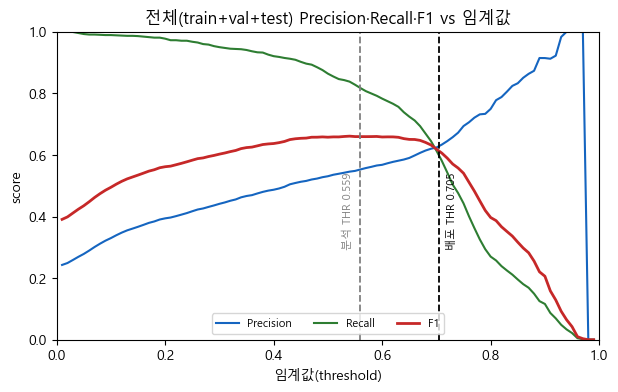

=== DiffMG 관계 중요도 α_r 상위 8 (가중치 초기값 1/R=0.0455) ===


,관계(한글),관계_원본,α_r,균등대비(배)
0,유사상품(공유키워드),product__sim_kw__product,0.6136,13.50
1,역-유사상품(공유IP),product__rev_sim_ip__product,0.1049,2.31
2,유사상품(공유IP),product__sim_ip__product,0.1035,2.28
3,역-유사상품(공유키워드),product__rev_sim_kw__product,0.0486,1.07
4,역-키워드보유,keyword__rev_has_kw__product,0.0073,0.16
5,역-트렌드경유키워드,keyword__rev_has_kw_trend__product,0.0072,0.16
6,역-IP경유키워드,keyword__rev_has_kw_via_ip__product,0.0072,0.16
7,역-IP보유,ip__rev_has_ip__product,0.0072,0.16


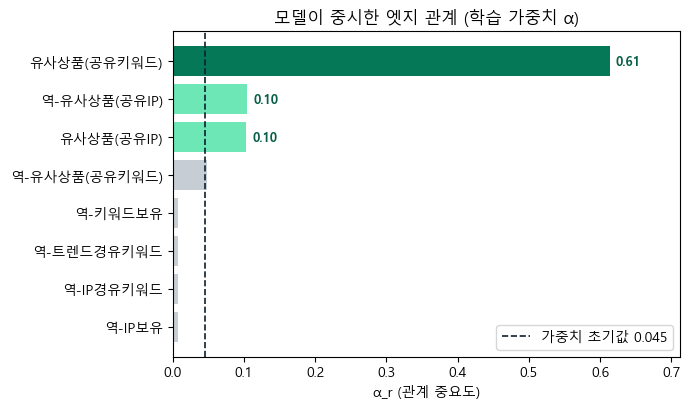

In [4]:
# [M0] 최종 성능 + α_r 중요 엣지 관계 (hero: α_r 막대)
ri=json.load(open(EXP_DIR/'relation_importance.json',encoding='utf-8'))
perf=pd.DataFrame(mj).T.reindex(['train','val','test'])[['pr_auc','auc_roc','f1','threshold']].round(4)
perf.index.name='분할'; perf.columns=['PR_AUC','ROC_AUC','F1','임계값']
print('=== v2_sweepA 최종 성능 (랜덤 PR-AUC≈%.3f) ==='%y_np[al].mean()); display(perf)
print('[참고] 전체(train+val+test) PR-AUC=%.4f (train 포함 — 성능 주장 아님, 구조분석 모집단 확인용)'%compute_metrics(y_np,prob)['pr_auc'])
from sklearn.metrics import confusion_matrix as _cmf
_thr=mj['val']['threshold']; _cm=_cmf(y_np[al],(prob[al]>=_thr).astype(int))
cm_tbl=pd.DataFrame(_cm,index=['실제 실패','실제 성공'],columns=['예측 실패','예측 성공'])
print(f'=== 전체(train+val+test) 혼동행렬 (THR={_thr:.4f}, n={int(al.sum())}) ==='); display(cm_tbl)
_thr_op=mj.get('operating_point',{}).get('thr',_thr); _cm_op=_cmf(y_np[al],(prob[al]>=_thr_op).astype(int))
cm_tbl_op=pd.DataFrame(_cm_op,index=['실제 실패','실제 성공'],columns=['예측 실패','예측 성공'])
print(f'=== 전체(train+val+test) 혼동행렬 — 배포 운영점 (THR={_thr_op:.4f}; 위는 분석용 val F1-max={_thr:.4f}) ==='); display(cm_tbl_op)
# [M0] test Precision·Recall·F1 vs 임계값 (분석 THR · 배포 THR 점선)
_ths=np.linspace(0.01,0.99,99); _yt=y_np[al]; _pp=prob[al]; _P=[]; _R=[]; _F=[]
for _t in _ths:
    _pr=(_pp>=_t).astype(int); _tp=int(((_pr==1)&(_yt==1)).sum()); _fp=int(((_pr==1)&(_yt==0)).sum()); _fn=int(((_pr==0)&(_yt==1)).sum())
    _p=_tp/(_tp+_fp) if _tp+_fp else 0.0; _r=_tp/(_tp+_fn) if _tp+_fn else 0.0
    _P.append(_p); _R.append(_r); _F.append(2*_p*_r/(_p+_r) if (_p+_r) else 0.0)
figp,axp=plt.subplots(figsize=(7,4))
axp.plot(_ths,_P,label='Precision',color='#1565c0'); axp.plot(_ths,_R,label='Recall',color='#2e7d32'); axp.plot(_ths,_F,label='F1',color='#c62828',lw=2)
axp.axvline(_thr,ls='--',color='gray',lw=1.3); axp.axvline(_thr_op,ls='--',color='black',lw=1.3)
axp.text(_thr-0.012,0.42,f'분석 THR {_thr:.3f}',rotation=90,va='center',ha='right',fontsize=8,color='gray')
axp.text(_thr_op+0.012,0.42,f'배포 THR {_thr_op:.3f}',rotation=90,va='center',ha='left',fontsize=8,color='black')
axp.set_xlabel('임계값(threshold)'); axp.set_ylabel('score'); axp.set_xlim(0,1); axp.set_ylim(0,1)
axp.legend(loc='lower center',ncol=3,fontsize=8); axp.set_title('전체(train+val+test) Precision·Recall·F1 vs 임계값')
savefig(figp,'m0_prf.png'); plt.show()
R=len(ri[0]); base=1.0/R
_NODEKR={'product':'상품','keyword':'키워드','ip':'IP'}
# 임원용 직관 라벨: 두 노드가 무엇을 통해 이어지는지를 '(상품 - IP - 상품)' 식 경로로 표기
_PATHKR={'sim_kw':'상품 - 키워드 - 상품','sim_ip':'상품 - IP - 상품',
         'has_kw_via_ip':'상품 - IP - 키워드','has_kw_ipip':'상품 - IP - IP - 키워드',
         'has_kw_trend':'상품 - 트렌드 - 키워드','trend_to':'키워드 - 키워드(트렌드)',
         'basket_comp':'키워드 - 키워드(장바구니)'}
def _lab(cc,pair):
    if cc in _PATHKR: core=_PATHKR[cc]
    else:
        nodes=[_NODEKR.get(x,x) for x in pair]
        if '상품' in nodes: nodes=sorted(nodes,key=lambda n:n!='상품')   # 상품을 앞에
        core=' - '.join(nodes)
    return f'({core})'
# 정·역 방향은 같은 (무방향) 관계라 α를 합산해 관계별 1막대로 (예: (상품-IP-상품) = 정0.10+역0.10=0.21)
from collections import defaultdict as _dd
_mg=_dd(lambda:[0.0,[]])
for _k,_v in ri[0].items():
    _a,_core,_b=_k.split('__'); _cc=_core.replace('rev_','')
    _key=(tuple(sorted([_a,_b])),_cc); _mg[_key][0]+=_v; _mg[_key][1].append(_k)
R=len(_mg); base=1.0/R   # 합산 후 관계 수(11) → 균등 초기값=1/11
_rows=[{'관계(한글)':_lab(_cc,_pair),'관계_원본':' + '.join(sorted(_ks)),'α_r':_s}
       for (_pair,_cc),(_s,_ks) in _mg.items()]
rel=pd.DataFrame(_rows).sort_values('α_r',ascending=False).reset_index(drop=True).head(8).copy()
rel['균등대비(배)']=(rel['α_r']/base).round(2); rel['α_r']=rel['α_r'].round(4)
rel=rel[['관계(한글)','관계_원본','α_r','균등대비(배)']]
print(f'=== 모델이 중요시한 연결 관계 (학습 가중치 α, 정·역 합산 {R}개 · 균등 초기값 1/{R}={base:.4f}) ==='); display(rel)
# hero 그림
fig,ax=plt.subplots(figsize=(7.4,4.2)); rr=rel.iloc[::-1]
import matplotlib.colors as _mc
_GKW=np.array(_mc.to_rgb('#047857')); _GIP=np.array(_mc.to_rgb('#6EE7B7'))  # 진초록=핵심 신호, 옅은초록=보조
_sig=[v>=base*1.5 for v in rr['α_r']]; _sv=[v for v,s in zip(rr['α_r'],_sig) if s]
_vmin,_vmax=(min(_sv),max(_sv)) if _sv else (0.0,1.0); _rng=(_vmax-_vmin) or 1.0
_cols=[tuple(_GIP*(1-(v-_vmin)/_rng)+_GKW*((v-_vmin)/_rng)) if s else '#C7CDD4' for v,s in zip(rr['α_r'],_sig)]
ax.barh(rr['관계(한글)'],rr['α_r'],color=_cols)
ax.set_xlim(0,max(rr['α_r'])*1.16)
for _y,(v,s) in enumerate(zip(rr['α_r'],_sig)):
    if s: ax.text(v+0.008,_y,f'{v:.2f}',va='center',ha='left',fontsize=9,fontweight='bold',color='#065F46')
ax.axvline(base,ls='--',c='#0D1F2D',lw=1.2,label=f'학습 전 기본값(균등) {base:.3f}')
ax.set_xlabel('연결 중요도 (학습 가중치 α)'); ax.set_title('모델이 중요시한 연결 관계'); ax.legend()
plt.tight_layout(); savefig(fig,'m0_alpha.png'); plt.show()

THR=0.5593 | 전체 사분면: {'TP': 981, 'FP': 792, 'FN': 216, 'TN': 3044}


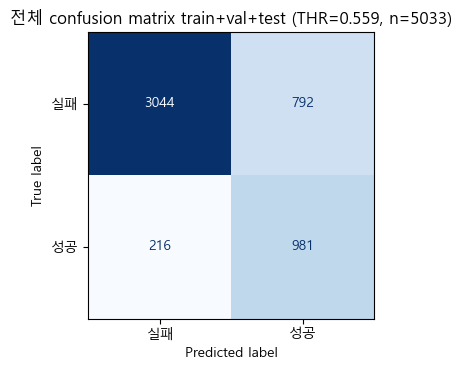

장부(전체 라벨): 고성공 81개(>= 0.50) / 고실패 106개(<= 0.00)


In [5]:
# [M0-d] df·THR·test 사분면·confusion matrix(test) + train+val 장부
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
pnodes=pd.read_parquet(SHARE_HIN/'product_nodes_final.parquet')
assert pnodes['ITEM_CD'].map(norm_id).tolist()==maps['product_ids']
split=np.where(tr,'train',np.where(va,'val','test'))
df=pd.DataFrame({'pid':maps['product_ids'],'ITEM_NM':pnodes['ITEM_NM'].values,'편의점명':pnodes['편의점명'].values,
  '성공_소스':pnodes['성공_소스'].values,'kw_cnt':pnodes['키워드_개수'].fillna(0).astype(int).values,
  'insta_m30':pnodes['insta_mention_30d'].fillna(0).values,'has_promo':data['product'].has_promo.cpu().numpy(),
  'pred':prob,'y_true':y_np,'split':split})
def f1max_thr(yv,pv):
    pr,rc,th=precision_recall_curve(yv,pv); f1=2*pr*rc/(pr+rc+1e-12); i=int(np.nanargmax(f1)); return float(th[min(i,len(th)-1)])
THR=f1max_thr(df[df.split=='val'].y_true,df[df.split=='val'].pred); assert abs(THR-mj['val']['threshold'])<0.05
df['quad']=np.where((df.pred>=THR)&(df.y_true==1),'TP',np.where((df.pred>=THR)&(df.y_true==0),'FP',
           np.where((df.pred<THR)&(df.y_true==1),'FN','TN')))
test=df.copy()  # 전체(train+val+test) 분석 대상
print('THR=%.4f | 전체 사분면:'%THR, test['quad'].value_counts().reindex(QORDER).to_dict())
cm=confusion_matrix(test.y_true,(test.pred>=THR).astype(int))
fig,ax=plt.subplots(figsize=(4.2,3.8)); ConfusionMatrixDisplay(cm,display_labels=['실패','성공']).plot(ax=ax,colorbar=False,cmap='Blues')
ax.set_title(f'전체 confusion matrix train+val+test (THR={THR:.3f}, n={len(test)})'); plt.tight_layout(); savefig(fig,'m0_cm.png'); plt.show()
# 전체 라벨 장부(홀드아웃 없음)
P=len(maps['product_ids']); pid2idx={p:i for i,p in enumerate(maps['product_ids'])}
pk=pd.read_parquet(SHARE_HIN/'product_keyword_edges_final.parquet'); pk['pid']=pk['ITEM_CD'].map(norm_id)
pi=pd.read_parquet(SHARE_HIN/'product_ip_edges_final.parquet'); pi['pid']=pi['ITEM_CD'].map(norm_id)
knodes=pd.read_parquet(SHARE_HIN/'keyword_nodes_final.parquet'); trend_set=set(knodes.loc[knodes['is_trend_keyword']==1,'keyword'])
kw_by_prod=pk.groupby('pid')['keyword'].apply(list); ip_by_prod=pi.groupby('pid')['ip_name'].apply(list)
tv_pids=set(df['pid'])  # 전체 라벨(홀드아웃 없음)
ytv=df.set_index('pid')['y_true']
pk_tv=pk[pk['pid'].isin(tv_pids)].join(ytv,on='pid')
ks=pk_tv.groupby('keyword')['y_true'].agg(['mean','count']); MIN=5; ko=ks[ks['count']>=MIN]
hi,lo=ko['mean'].quantile(0.9),ko['mean'].quantile(0.1)
kw_succ=set(ko[ko['mean']>=hi].index); kw_fail=set(ko[ko['mean']<=lo].index)
kw_pop=pk[pk['pid'].isin(tv_pids)].groupby('keyword')['pid'].nunique()
print(f'장부(전체 라벨): 고성공 {len(kw_succ)}개(>= {hi:.2f}) / 고실패 {len(kw_fail)}개(<= {lo:.2f})')

## M1·M2 — 노드 피처 & 관계 참여 4분면 대조 (test-only)
🎯 **목표**: FP/FN이 *자기 콘텐츠*(키워드·IP·promo)와 *엣지 보유/차수*에서 TP/TN과 다른가.
✅ **결론**: 예측성공(TP·FP)일수록 **유사키워드·유사IP 차수·프로모션·고성공키워드↑**. FN은 이들이 약하고, FP는 트렌드비율 최고(낚시). 모두 채널 독립 피처.

=== 노드 피처·관계 차수 4분면 평균 (상세) ===


,키워드수,IP수,트렌드키워드비율,고성공키워드비율,고실패키워드비율,키워드일반성(hub),프로모션여부,인스타30일언급,유사키워드_차수,유사IP_차수,IP연결_차수
사분면,,,,,,,,,,,
TP,8.742,0.408,0.586,0.066,0.000,470.105,0.574,0.865,349.263,8.738,0.388
FP,8.096,0.227,0.612,0.028,0.011,474.981,0.641,0.606,320.414,5.383,0.218
FN,8.051,0.185,0.572,0.039,0.000,411.943,0.157,0.662,285.273,1.903,0.167
TN,6.769,0.195,0.498,0.013,0.042,335.060,0.119,0.625,128.151,2.145,0.188


,FP_vs_TN,FN_vs_TP
키워드수,9.2e-36*,2.1e-03*
IP수,1.8e-02*,7.0e-09*
트렌드키워드비율,1.4e-38*,3.0e-01
고성공키워드비율,1.4e-13*,3.7e-04*
고실패키워드비율,3.1e-21*,1.0e+00
키워드일반성(hub),6.3e-53*,6.3e-04*
프로모션여부,0.0e+00*,1.6e-28*
인스타30일언급,8.6e-09*,4.6e-01
유사키워드_차수,2.0e-82*,1.7e-04*
유사IP_차수,9.7e-05*,3.4e-09*


[고성공 키워드 예시] 성공률: 관람(1.00), 로코모코(1.00), 땡초(0.83), 알포트(0.83), 하와이(0.83), 박카스(0.80), 메타몽(0.80), 고창(0.80)
[고실패 키워드 예시] 등장수: 캔(39), 다리(26), 찌개(23), 하림(18), 블렌디드(17), 식빵(16), 페어링(16), 빅(15)
[키워드 일반성 높음=흔한 키워드] 등장 제품수: 간식(2476), 달콤(1296), 야식(780), 디저트(716), 부드러움(687), 고소(563), 식사(553), 초코(540)


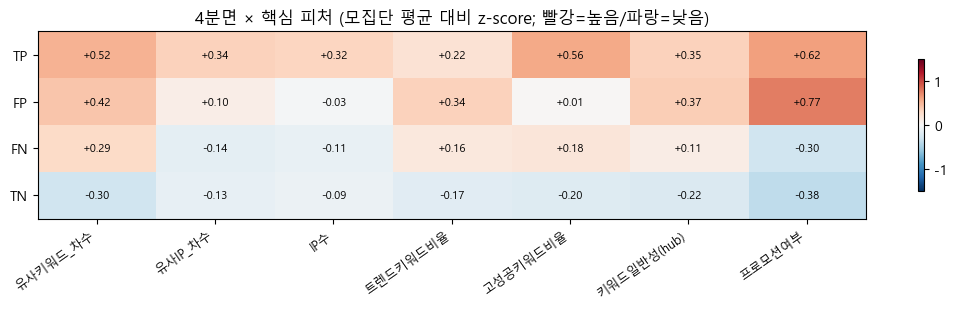

In [6]:
# [M1+M2] 노드 피처 & 관계 차수 (hero: z-score 히트맵)
from scipy.stats import mannwhitneyu
def _ratio(p,S):
    kws=kw_by_prod.get(p,[]); return float(np.mean([k in S for k in kws])) if len(kws) else 0.0
def _deg(et): return np.bincount(data[et].edge_index[0].cpu().numpy(),minlength=P) if et in data.edge_types else np.zeros(P,dtype=int)
deg={r:_deg(('product',r,'ip') if r=='has_ip' else ('product',r,'product')) for r in ['sim_kw','sim_ip','has_ip']}
feat=pd.DataFrame({'사분면':test['quad'].values,
  '키워드수':test['kw_cnt'].values,
  'IP수':test['pid'].map(lambda p: len(ip_by_prod.get(p,[]))).values,
  '트렌드키워드비율':test['pid'].map(lambda p:_ratio(p,trend_set)).values,
  '고성공키워드비율':test['pid'].map(lambda p:_ratio(p,kw_succ)).values,
  '고실패키워드비율':test['pid'].map(lambda p:_ratio(p,kw_fail)).values,
  '키워드일반성(hub)':test['pid'].map(lambda p: float(np.mean([kw_pop.get(k,0) for k in kw_by_prod.get(p,[])])) if len(kw_by_prod.get(p,[])) else 0.0).values,
  '프로모션여부':test['has_promo'].values,'인스타30일언급':test['insta_m30'].values,
  '유사키워드_차수':test['pid'].map(lambda p:int(deg['sim_kw'][pid2idx[p]])).values,
  '유사IP_차수':test['pid'].map(lambda p:int(deg['sim_ip'][pid2idx[p]])).values,
  'IP연결_차수':test['pid'].map(lambda p:int(deg['has_ip'][pid2idx[p]])).values})
COLS=[c for c in feat.columns if c!='사분면']
qm=feat.groupby('사분면')[COLS].mean().reindex(QORDER)
print('=== 노드 피처·관계 차수 4분면 평균 (상세) ==='); display(qm.round(3))
def mwu(a,b,col):
    ga=feat[feat['사분면']==a][col].dropna(); gb=feat[feat['사분면']==b][col].dropna()
    return float('nan') if len(ga)<3 or len(gb)<3 else mannwhitneyu(ga,gb,alternative='two-sided')[1]
sig=pd.DataFrame({'FP_vs_TN':{x:mwu('FP','TN',x) for x in COLS},'FN_vs_TP':{x:mwu('FN','TP',x) for x in COLS}})
display(sig.apply(lambda s:s.map(lambda p:'' if p!=p else f'{p:.1e}'+('*' if p<0.05 else ''))))
# 파생 지표 예시 (고성공/고실패 키워드 · 키워드 일반성)
_es=ko.loc[sorted(kw_succ)].sort_values('mean',ascending=False).head(8)
_ef=ko.loc[sorted(kw_fail)].sort_values('count',ascending=False).head(8)
print('[고성공 키워드 예시] 성공률:', ', '.join(f'{k}({v:.2f})' for k,v in _es['mean'].items()))
print('[고실패 키워드 예시] 등장수:', ', '.join(f'{k}({int(c)})' for k,c in _ef['count'].items()))
print('[키워드 일반성 높음=흔한 키워드] 등장 제품수:', ', '.join(f'{k}({int(v)})' for k,v in kw_pop.sort_values(ascending=False).head(8).items()))
# hero: z-score 히트맵 (핵심 피처)
key=['유사키워드_차수','유사IP_차수','IP수','트렌드키워드비율','고성공키워드비율','키워드일반성(hub)','프로모션여부']
Z=(qm[key]-feat[key].mean())/ (feat[key].std(ddof=0)+1e-9)
fig,ax=plt.subplots(figsize=(11,3.2)); im=ax.imshow(Z.values,cmap='RdBu_r',vmin=-1.5,vmax=1.5,aspect='auto')
ax.set_xticks(range(len(key))); ax.set_xticklabels(key,rotation=35,ha='right',fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(QORDER)
for i in range(4):
    for j in range(len(key)): ax.text(j,i,f'{Z.values[i,j]:+.2f}',ha='center',va='center',fontsize=8)
ax.set_title('4분면 × 핵심 피처 (모집단 평균 대비 z-score; 빨강=높음/파랑=낮음)'); plt.colorbar(im,ax=ax,shrink=0.7)
plt.tight_layout(); savefig(fig,'m1m2_heatmap.png'); plt.show()

## M3 ★ — 고-α 관계 이웃의 라벨 구성 (test, 인과 핵심)
🎯 **목표**: 점수를 지배하는 관계(유사상품 sim_kw·sim_ip)의 **이웃이 성공/실패 어디로 쏠리나**.
✅ **결론**: **유사상품(IP) 이웃 성공률이 예측을 가른다** — 예측성공(TP·FP) 0.53~0.60 vs 예측실패(FN·TN) 0.14~0.22. FP는 성공작과 닮은 IP/외형으로 과대, FN은 닮은 성공작이 없어 못 끌어올림. 유사키워드(sim_kw)는 거의 전 제품이 보유(보유율~1.0)해 성공률 차이가 작은 약한 신호. 모든 신호가 채널 독립이라 채널 전제 없이 해석.

전체 기준 성공률 = 0.238
=== 관계별 이웃 성공률 (상세) ===


,유사상품(공유키워드)_이웃성공률,유사상품(공유IP)_이웃성공률
사분면,,
TP,0.399,0.599
FP,0.379,0.542
FN,0.318,0.270
TN,0.278,0.158


=== 관계 엣지 보유율 (상세) ===


,유사상품(공유키워드)_이웃보유율,유사상품(공유IP)_이웃보유율
사분면,,
TP,0.980,0.326
FP,0.986,0.192
FN,0.972,0.125
TN,0.931,0.144


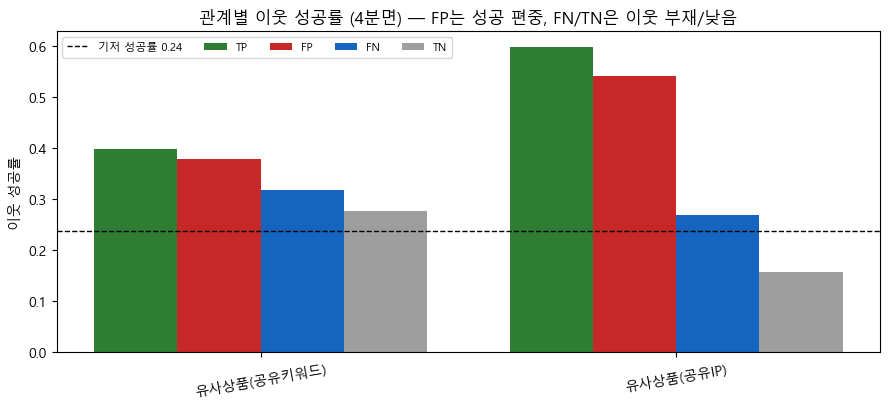

=== sim_ip 이웃 성공 구성 (분면별 전체 ego, full 이웃라벨, 양방향) ===


,sim_ip 이웃 연결수,성공 이웃 수,성공 이웃 비율
분면,,,
TP,17144,9950,0.580
FP,8526,4750,0.557
FN,822,210,0.255
TN,13060,3056,0.234
전체,39552,17966,0.454


> 분면별 **절대 개수**로 본 같은 패턴: 예측성공 TP 58%·FP 56% vs 예측실패 FN 26%·TN 23% (이웃 라벨=전체 데이터, 양방향 incidence). 위 평균-성공률 표와 동일 결론을 개수로 확인.


In [7]:
# [M3] 관계별 이웃 성공률 + 보유율 (hero: 그룹막대)
PROD_REL=['co_offline','co_quick','sim_kw','sim_ip']
REL_KR={'co_offline':'오프라인동반구매','co_quick':'퀵커머스동반구매','sim_kw':'유사상품(공유키워드)','sim_ip':'유사상품(공유IP)'}
def neigh_rate(et):
    ei=data[et].edge_index.cpu().numpy(); s=np.concatenate([ei[0],ei[1]]); d=np.concatenate([ei[1],ei[0]])
    keep=al[d]; s,d=s[keep],d[keep]
    cnt=np.bincount(s,minlength=P).astype(float); succ=np.bincount(s,weights=y_np[d].astype(float),minlength=P)
    return np.where(cnt>0,succ/cnt,np.nan), cnt
for r in PROD_REL:
    et=('product',r,'product')
    if et in data.edge_types:
        rate,cnt=neigh_rate(et)
        test[r+'_nbr_succ']=test['pid'].map(lambda p,a=rate: a[pid2idx[p]])
        test[r+'_nbr_has']=test['pid'].map(lambda p,c=cnt: bool(c[pid2idx[p]]>0))
ncols=[r+'_nbr_succ' for r in PROD_REL if r+'_nbr_succ' in test]; hcols=[r+'_nbr_has' for r in PROD_REL if r+'_nbr_has' in test]
relnames=[r for r in PROD_REL if r+'_nbr_succ' in test]; baseline=float(y_np.mean())
succ_tbl=test.groupby('quad')[ncols].mean().reindex(QORDER).round(3); succ_tbl.columns=[REL_KR[r]+'_이웃성공률' for r in relnames]; succ_tbl.index.name='사분면'
has_tbl=test.groupby('quad')[hcols].mean().reindex(QORDER).round(3); has_tbl.columns=[REL_KR[r]+'_이웃보유율' for r in relnames]; has_tbl.index.name='사분면'
print('전체 기준 성공률 = %.3f'%baseline)
print('=== 관계별 이웃 성공률 (상세) ==='); display(succ_tbl)
print('=== 관계 엣지 보유율 (상세) ==='); display(has_tbl)
# hero: 그룹막대 (관계별 이웃성공률, 사분면별)
gm=test.groupby('quad')[ncols].mean().reindex(QORDER)
fig,ax=plt.subplots(figsize=(9,4.2)); x=np.arange(len(relnames)); w=0.2
for i,q in enumerate(QORDER):
    ax.bar(x+(i-1.5)*w,[gm.loc[q,cc] for cc in ncols],w,label=q,color=QCOLOR[q])
ax.axhline(baseline,ls='--',c='k',lw=1,label=f'기저 성공률 {baseline:.2f}')
ax.set_xticks(x); ax.set_xticklabels([REL_KR[r] for r in relnames],rotation=10); ax.set_ylabel('이웃 성공률')
ax.set_title('관계별 이웃 성공률 (4분면) — FP는 성공 편중, FN/TN은 이웃 부재/낮음'); ax.legend(ncol=5,fontsize=8)
plt.tight_layout(); savefig(fig,'m3_nbr.png'); plt.show()

# 분면(TP/FP/FN/TN)별 sim_ip 이웃 성공 구성 — 절대 개수·비율 (ego=전체, 이웃 라벨=전체 train+val+test, 양방향 incidence)
_predall=(prob>=THR).astype(int)
_quadall=np.where((_predall==1)&(y_np==1),'TP',np.where((_predall==1)&(y_np==0),'FP',np.where((_predall==0)&(y_np==1),'FN','TN')))
_eii=data[('product','sim_ip','product')].edge_index.cpu().numpy()
_s=np.concatenate([_eii[0],_eii[1]]); _d=np.concatenate([_eii[1],_eii[0]]); _nbr=y_np[_d]; _egoq=_quadall[_s]; _iste=al[_s]
def _siprow(msk,lab):
    tot=int(msk.sum()); su=int(_nbr[msk].sum()); return {'분면':lab,'sim_ip 이웃 연결수':tot,'성공 이웃 수':su,'성공 이웃 비율':round(su/tot,3) if tot else np.nan}
simip_full=pd.DataFrame([_siprow((_egoq==q)&_iste,q) for q in ['TP','FP','FN','TN']]+[_siprow(_iste,'전체')]).set_index('분면')
simip_note='> 분면별 **절대 개수**로 본 같은 패턴: 예측성공 TP %.0f%%·FP %.0f%% vs 예측실패 FN %.0f%%·TN %.0f%% (이웃 라벨=전체 데이터, 양방향 incidence). 위 평균-성공률 표와 동일 결론을 개수로 확인.'%(simip_full.loc['TP','성공 이웃 비율']*100,simip_full.loc['FP','성공 이웃 비율']*100,simip_full.loc['FN','성공 이웃 비율']*100,simip_full.loc['TN','성공 이웃 비율']*100)
print('=== sim_ip 이웃 성공 구성 (분면별 전체 ego, full 이웃라벨, 양방향) ==='); display(simip_full); print(simip_note)


## M5 — 극단 사례 정성 + Ego-Network (test)
🎯 **목표**: 대표 FP/FN의 메커니즘을 키워드·IP·이웃 성공률로 서사화.
✅ **결론**: M3의 정량 결론(유사 성공작과의 연결)을 사례로 예시 — FP는 트렌디·간판 키워드가 많고 유사 성공작과 묶임, FN은 유사 성공작 연결이 약함. ※ 표본 적어 일반화 아님.

 FN Top (실제 성공, 낮은 pred)
[세븐일레븐] 훼밀리)복숭아무케루푸루푸루구미40g        pred=0.03 유사KW이웃=0.33 유사IP이웃=0.00 | 복숭아, 젤리, 간식
[GS25] 젼언니과일모양프룻팝스                pred=0.03 유사KW이웃=0.39 유사IP이웃=0.00 | 과즙, 간식, 복숭아, 딸기, 포도, 디저트, 망고, 달콤, 과일
[GS25] NCTDREAMXGS25아이돌컴백샌드위치     pred=0.03 유사KW이웃=0.17 유사IP이웃=0.00 | 샌드, 샌드위치, 빵, NCT, 아이돌
[세븐일레븐] 훼밀리)사과무케루푸루푸루구미40g         pred=0.03 유사KW이웃=0.25 유사IP이웃=nan | 젤리, 사과, 과일, 무
[GS25] 요아정요거트초코쉘팝팝콘딸              pred=0.03 유사KW이웃=0.32 유사IP이웃=0.12 | 초코, 요거트, 딸기, 디저트, 과자, 크림, 농심, CJ, 롯데, 쉘
[세븐일레븐] PB)요구르트280ml               pred=0.04 유사KW이웃=0.50 유사IP이웃=nan | 유산균, 요거트, 간식
[CU] 빵빵이의얼큰포장마차어묵국수             pred=0.04 유사KW이웃=0.00 유사IP이웃=0.00 | 어묵, 포장마차, 국수, 시원, 매콤, 얼큰함
[세븐일레븐] 제스)모리나가밀크카라멜모나카97g         pred=0.05 유사KW이웃=0.27 유사IP이웃=nan | 카라멜, 밀크, 일본, 디저트, 간식, 모나카🔥
 FP Top (실제 실패, 높은 pred)
[CU] 야끼소바도그                     pred=0.93 유사KW이웃=0.57 유사IP이웃=0.62 | 식사, 핫도그, 달콤, 가쓰오부시, 마요, 짭조름함, 콜라, 야끼소바
[CU] TXT별모아쿠키                   pred=0.93 유사KW이웃=0.65 유사IP이웃=0.86 | 쿠키, 과자, 고소, 시즌🔥
[CU] KBO돌

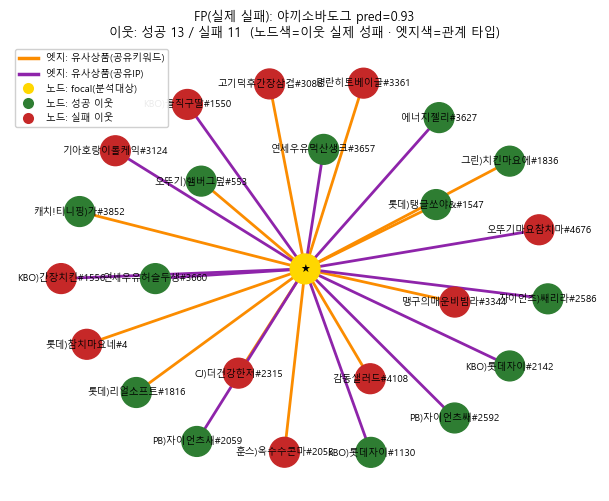

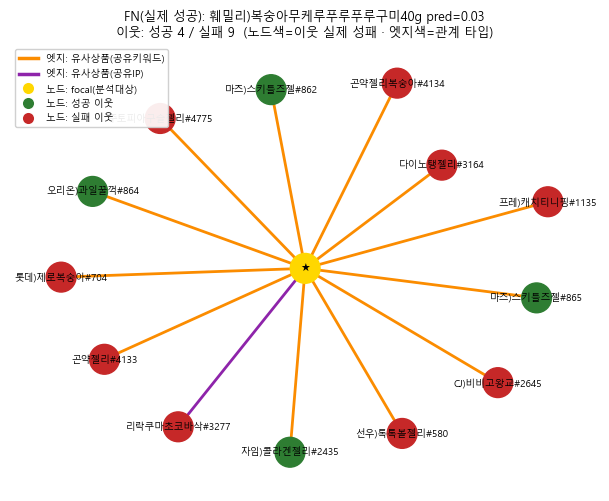

In [8]:
# [M5] FP/FN Top + ego-net (test)
def tag(k): return f'{k}{"🔥" if k in kw_succ else ("💣" if k in kw_fail else "")}'
def show(sub,title,n=8):
    print('='*64,'\n',title)
    for _,r in sub.head(n).iterrows():
        kws=', '.join(tag(k) for k in kw_by_prod.get(r['pid'],[])[:10])
        sk=r.get('sim_kw_nbr_succ',np.nan); si=r.get('sim_ip_nbr_succ',np.nan)
        print(f"[{r['편의점명']}] {str(r['ITEM_NM'])[:26]:<26} pred={r['pred']:.2f} 유사KW이웃={sk:.2f} 유사IP이웃={si:.2f} | {kws}")
fn=test[test.quad=='FN'].sort_values('pred'); fp=test[test.quad=='FP'].sort_values('pred',ascending=False)
show(fn,'FN Top (실제 성공, 낮은 pred)'); show(fp,'FP Top (실제 실패, 높은 pred)')
print('\n태그: 🔥고성공 키워드 / 💣고실패 키워드')
import networkx as nx
from matplotlib.lines import Line2D
REL_EDGE={'sim_kw':('유사상품(공유키워드)','#fb8c00'),'sim_ip':('유사상품(공유IP)','#8e24aa')}
def ego(pid,title,fname,cap=12):
    G=nx.Graph(); G.add_node('★',role='focal')
    i=pid2idx[pid]; ns=nf=0
    for r in ['sim_kw','sim_ip']:  # α 우선순위 (한 이웃이 복수 관계면 앞선 것 유지)
        et=('product',r,'product')
        if et not in data.edge_types: continue
        ei=data[et].edge_index.cpu().numpy()
        nbr=set(ei[1][ei[0]==i]).union(set(ei[0][ei[1]==i])); nbr.discard(i)
        for j in list(nbr)[:cap]:
            lab='성공' if y_np[j]==1 else '실패'
            nm=f"{str(maps['product_names'][j])[:8]}#{j}"
            if nm not in G: G.add_node(nm,role=lab); ns+=(lab=='성공'); nf+=(lab=='실패')
            if not G.has_edge('★',nm): G.add_edge('★',nm,rel=r)
    cmap={'focal':'gold','성공':'#2e7d32','실패':'#c62828'}
    pos=nx.spring_layout(G,seed=1,k=0.7)
    fig,ax=plt.subplots(figsize=(7.6,5.8))
    nx.draw_networkx_nodes(G,pos,ax=ax,node_size=460,node_color=[cmap[G.nodes[x]['role']] for x in G])
    nx.draw_networkx_labels(G,pos,ax=ax,font_family='Malgun Gothic',font_size=7)
    present=[]
    for r,(rlab,rc) in REL_EDGE.items():
        el=[(u,v) for u,v,d in G.edges(data=True) if d.get('rel')==r]
        if not el: continue
        nx.draw_networkx_edges(G,pos,edgelist=el,ax=ax,edge_color=rc,width=2.0)
        present.append((rlab,rc))
    handles=[Line2D([0],[0],color=rc,lw=2.5,label=f'엣지: {rlab}') for rlab,rc in present]
    handles+=[Line2D([0],[0],marker='o',color='w',markerfacecolor='gold',markersize=9,label='노드: focal(분석대상)'),
              Line2D([0],[0],marker='o',color='w',markerfacecolor=cmap['성공'],markersize=9,label='노드: 성공 이웃'),
              Line2D([0],[0],marker='o',color='w',markerfacecolor=cmap['실패'],markersize=9,label='노드: 실패 이웃')]
    ax.legend(handles=handles,fontsize=7,loc='upper left',framealpha=0.92)
    ax.set_title(f'{title}\n이웃: 성공 {ns} / 실패 {nf}  (노드색=이웃 실제 성패 · 엣지색=관계 타입)',fontsize=9)
    ax.axis('off')
    savefig(fig,fname); plt.show()
if len(fp): ego(fp.iloc[0]['pid'],f"FP(실제 실패): {fp.iloc[0]['ITEM_NM']} pred={fp.iloc[0]['pred']:.2f}",'m5_ego_fp.png')
if len(fn): ego(fn.iloc[0]['pid'],f"FN(실제 성공): {fn.iloc[0]['ITEM_NM']} pred={fn.iloc[0]['pred']:.2f}",'m5_ego_fn.png')

In [9]:
# [M5b] 인터랙티브 ego HTML (pyvis) — 공유 키워드/IP 노드까지 펼침 (PNG 불변)
from pyvis.network import Network
HTML_REL={'sim_kw':('유사키워드','#fb8c00'),'sim_ip':('유사IP','#8e24aa')}  # product-product 엣지 타입색 (PNG와 동일)
def ego_html(pid,title,fname,cap=10,min_bridge=1):
    i=pid2idx[pid]
    net=Network(height='760px',width='100%',bgcolor='#ffffff',font_color='#222',directed=False,cdn_resources='in_line')
    net.barnes_hut(gravity=-12000,spring_length=160,spring_strength=0.02)
    fid=f'P{i}'
    net.add_node(fid,label='★ '+str(maps['product_names'][i])[:16],color='gold',shape='star',size=36,
                 title='분석대상(focal): '+str(maps['product_names'][i]))
    nbrs={}
    for r in ['sim_kw','sim_ip']:
        et=('product',r,'product')
        if et not in data.edge_types: continue
        ei=data[et].edge_index.cpu().numpy()
        nb_=set(ei[1][ei[0]==i]).union(set(ei[0][ei[1]==i])); nb_.discard(i)
        for j in list(nb_)[:cap]:
            nbrs.setdefault(int(j),r)
    focal_kw=set(map(str,kw_by_prod.get(pid,[]))); focal_ip=set(map(str,ip_by_prod.get(pid,[])))
    share={}; kw_bridge={}; ip_bridge={}
    for j in nbrs:
        jpid=maps['product_ids'][j]
        sk=focal_kw & set(map(str,kw_by_prod.get(jpid,[])))
        si=focal_ip & set(map(str,ip_by_prod.get(jpid,[])))
        share[j]=(sk,si)
        for k in sk: kw_bridge[k]=kw_bridge.get(k,0)+1
        for p in si: ip_bridge[p]=ip_bridge.get(p,0)+1
    ns=nf=0
    for j,r in nbrs.items():
        suc=bool(y_np[j]==1); ns+=suc; nf+=(not suc)
        col='#2e7d32' if suc else '#c62828'
        net.add_node(f'P{j}',label=str(maps['product_names'][j])[:13],color=col,shape='dot',size=18,
                     title=str(maps['product_names'][j])+(' (성공)' if suc else ' (실패)'))
        rlab,rc=HTML_REL[r]
        net.add_edge(fid,f'P{j}',color=rc,width=2.5,title=rlab)
    for k,cnt in kw_bridge.items():
        if cnt<min_bridge: continue
        kid='K::'+k
        net.add_node(kid,label=k,color='#111111',shape='diamond',size=9+4*min(cnt,5),
                     title=f'공유 키워드: {k} (이웃 {cnt}개 연결)',font={'color':'#111111'})
        net.add_edge(fid,kid,color='#000000',width=1)
        for j,(sk,si) in share.items():
            if k in sk: net.add_edge(kid,f'P{j}',color='#000000',width=1)
    for p,cnt in ip_bridge.items():
        if cnt<min_bridge: continue
        iid='I::'+p
        net.add_node(iid,label=p,color='#111111',shape='square',size=11+4*min(cnt,5),
                     title=f'공유 IP: {p} (이웃 {cnt}개 연결)',font={'color':'#111111'})
        net.add_edge(fid,iid,color='#000000',width=1)
        for j,(sk,si) in share.items():
            if p in si: net.add_edge(iid,f'P{j}',color='#000000',width=1)
    try: net.write_html(str(ASSETS/fname),notebook=False,open_browser=False)
    except TypeError: net.write_html(str(ASSETS/fname))
    # 고정 범례 박스를 HTML에 주입 (net.heading 대신 — 깨짐 방지)
    _lg=("<div style=\"position:fixed;top:10px;left:10px;z-index:999;background:rgba(255,255,255,.93);"
         "border:1px solid #bbb;border-radius:6px;padding:8px 11px;font:12px/1.7 'Malgun Gothic',sans-serif;color:#222\">"
         f"<b>{title}</b> &nbsp;(이웃 성공 {ns} / 실패 {nf})<br>"
         "<span style='color:#DAA520'>\u2605</span> 분석대상 &nbsp;"
         "<span style='color:#2e7d32'>\u25CF</span> 성공 이웃 &nbsp;"
         "<span style='color:#c62828'>\u25CF</span> 실패 이웃<br>"
         "<span style='color:#111'>\u25C6</span> 공유 키워드 &nbsp;"
         "<span style='color:#111'>\u25A0</span> 공유 IP<br>"
         "<span style='color:#fb8c00'>\u2501\u2501</span> 유사키워드 &nbsp;"
         "<span style='color:#8e24aa'>\u2501\u2501</span> 유사IP &nbsp;"
         "<span style='color:#000'>\u2501\u2501</span> 공유노드 경유</div>")
    _p=ASSETS/fname; _h=open(_p,encoding='utf-8').read()
    _css="<style>html,body{margin:0;padding:0;height:100%;overflow:hidden;background:#fff}.card{border:none!important;margin:0!important;width:100%!important;height:100vh!important;box-shadow:none!important;border-radius:0!important}#mynetwork{height:100vh!important;width:100vw!important;border:none!important;padding:0!important}</style>"
    _h=_h.replace('</head>', _css+'</head>')
    _h=_h.replace('<h1></h1>','')
    _h=_h.replace('</body>', _lg+'\n</body>')
    open(_p,'w',encoding='utf-8').write(_h)
    print(f'[HTML] {fname}: 이웃 성공{ns}/실패{nf}, 공유키워드 {len(kw_bridge)} / 공유IP {len(ip_bridge)}')
if len(fp): ego_html(fp.iloc[0]['pid'],f"FP(실제 실패): {fp.iloc[0]['ITEM_NM']}",'m5_ego_fp.html')
if len(fn): ego_html(fn.iloc[0]['pid'],f"FN(실제 성공): {fn.iloc[0]['ITEM_NM']}",'m5_ego_fn.html')

[HTML] m5_ego_fp.html: 이웃 성공9/실패11, 공유키워드 6 / 공유IP 1


[HTML] m5_ego_fn.html: 이웃 성공4/실패7, 공유키워드 3 / 공유IP 1


## M7 — 종합 · α_r 교차

In [10]:
# [M7] 종합
print('DiffMG α_r 상위 (layer0):')
for k,v in sorted(ri[0].items(),key=lambda x:-x[1])[:6]: print(f'  {_relkr(k):<18}{v:.4f}')
_qd=test['quad'].value_counts().to_dict(); _fn=int(_qd.get('FN',0)); _fp=int(_qd.get('FP',0))
def _sip(q):
    try: return float(succ_tbl.loc[q,'유사상품(공유IP)_이웃성공률'])
    except Exception: return float('nan')
print(f'''
[종합 실패모드 - 채널 독립 신호(유사상품 sim_ip) 기준 · 전체 train+val+test]
- FN(놓친 성공, {_fn}개): 유사상품(IP) 이웃 성공률 낮음({_sip("FN"):.2f} vs TP {_sip("TP"):.2f}) -> 닮은 성공작 없는 신규 성공을 못 끌어올림.
- FP(낚인 실패, {_fp}개): 유사상품(IP) 이웃 성공 편중({_sip("FP"):.2f}) + 트렌드 키워드 -> 성공작과 닮은 외형/IP로 과대.
- 모델 신호: v2는 동반구매(co_*) 미사용 — alpha_r 최상위=유사키워드(sim_kw), 분면을 가르는 건 유사IP(sim_ip) 이웃 성공률.
- 처방: FN 보조 룰 / FP의 sim_ip 후광 보정.
''')

DiffMG α_r 상위 (layer0):
  유사상품(공유키워드)       0.6136
  역-유사상품(공유IP)      0.1049
  유사상품(공유IP)        0.1035
  역-유사상품(공유키워드)     0.0486
  역-키워드보유           0.0073
  역-트렌드경유키워드        0.0072

[종합 실패모드 - 채널 독립 신호(유사상품 sim_ip) 기준 · 전체 train+val+test]
- FN(놓친 성공, 216개): 유사상품(IP) 이웃 성공률 낮음(0.27 vs TP 0.60) -> 닮은 성공작 없는 신규 성공을 못 끌어올림.
- FP(낚인 실패, 792개): 유사상품(IP) 이웃 성공 편중(0.54) + 트렌드 키워드 -> 성공작과 닮은 외형/IP로 과대.
- 모델 신호: v2는 동반구매(co_*) 미사용 — alpha_r 최상위=유사키워드(sim_kw), 분면을 가르는 건 유사IP(sim_ip) 이웃 성공률.
- 처방: FN 보조 룰 / FP의 sim_ip 후광 보정.



## 📄 보고서 생성
아래 셀이 `network_eda_report.md`(모듈별 목표·그림·결론 + 종합)와 `report_assets/*.png`를 생성. Run All 시 노트북 수치와 자동 동기화.

In [11]:
# [보고서] network_eda_report.md 생성 (목표→방법/시각자료→결론, 결론은 시각자료 수치에 근거)
def df2md(d):
    d=d.reset_index() if (d.index.name or not isinstance(d.index,pd.RangeIndex)) else d.copy()
    cols=list(map(str,d.columns)); out=['| '+' | '.join(cols)+' |','|'+'|'.join(['---']*len(cols))+'|']
    for _,r in d.iterrows(): out.append('| '+' | '.join(str(r[c]) for c in d.columns)+' |')
    return '\n'.join(out)
def g(df,i,c):
    try: return float(df.loc[i,c])
    except Exception: return float('nan')
def gp(ch,jd,col):
    try: return float(prof.loc[(ch,jd),col])
    except Exception: return float('nan')
rndb=float(y_np[al].mean()); qd=test['quad'].value_counts().to_dict(); basep=float(y_np.mean())
cmtab=pd.DataFrame([[qd.get('TN',0),qd.get('FP',0)],[qd.get('FN',0),qd.get('TP',0)]],index=['실제 실패','실제 성공'],columns=['예측 실패','예측 성공'])
_thr_op=mj.get('operating_point',{}).get('thr',THR); _po=(prob>=_thr_op).astype(int)
cmtab_op=pd.DataFrame([[int(((_po[al]==0)&(y_np[al]==0)).sum()),int(((_po[al]==1)&(y_np[al]==0)).sum())],[int(((_po[al]==0)&(y_np[al]==1)).sum()),int(((_po[al]==1)&(y_np[al]==1)).sum())]],index=['실제 실패','실제 성공'],columns=['예측 실패','예측 성공'])
L=[]; A=L.append
def sec(num,title,goal,method,table,img,point,concl):
    A(f'## {num}. {title}\n'); A(f'### 🎯 분석 목표\n{goal}\n'); A(f'### 🔬 분석 방법\n{method}\n')
    if table: A(table+'\n')
    A(f'### 📊 핵심 시각자료\n![{title}](report_assets/{img})\n'); A(f'**📌 이 그림에서 볼 점** — {point}\n'); A(f'### ✅ 결론\n{concl}\n')

A('# v2_sweepA 오분류(FP/FN) 구조 진단 — 분석 보고서\n')
A(f'> 모델 `v2_sweepA` · 전체(train+val+test) {len(test)}개 · 운영 임계값 THR={THR:.4f}(val F1-max) · 노트북 Run All 시 자동 생성.\n')
A('## 0. 분석 개요 — 왜 / 무엇을 / 어떻게\n')
A(f'**배경**: v2_sweepA은 신제품 성공을 test PR-AUC **{mj["test"]["pr_auc"]:.3f}**(랜덤 {rndb:.3f}의 **{mj["test"]["pr_auc"]/rndb:.2f}배**)로 잘 순위화하나, 임계값(THR={THR:.3f})으로 잘랐을 때 **어떤 제품에서 왜 틀리는지**는 알 수 없다.\n')
A('**⚠ leak-free 모델**: v2_sweepA는 이전 exp41이 가장 의존하던 동반구매(co_offline, α 0.13)가 **출시-후 매출 누수**라 입력에서 제거하고, 그 가치를 키워드 보완재(basket_comp)·보조 예측 타깃으로 재배치한 모델이다. PR-AUC 0.696→0.608 하락은 *실력 저하가 아니라 증발한 누수*이며, 본 진단은 leak-free 모델의 정직한 오분류를 본다.\n')
A('**분석 질문**: 모델이 실제 성공을 놓치고(FN) 실제 실패에 낚이는(FP) **구조적 원인**을 노드·엣지·이웃 패턴에서 찾는다. 전체(train+val+test) 데이터를 TP/FP/FN/TN 4분면으로 분해(TP·TN을 정상 기준선으로 대조).\n')
A('**모델 신호 구성(v2_sweepA)**: 본 모델은 영수증 동반구매(co_offline/co_quick)를 **사용하지 않는다**. DiffMG 게이트가 분화시킨 신호는 **유사상품(공유키워드 sim_kw·공유IP sim_ip)** 위주이며, 모두 **채널 독립**(세븐·CU·GS25 공통)이다. 따라서 본 보고서는 채널 전용 전제 없이, *유사상품 이웃의 성패 구성*을 중심으로 오분류를 해석한다.\n')
A('**한눈 결론 (2대, 시각자료 수치 근거)**\n')
A(f'1. 🔴 **FN(놓친 성공)** — **유사상품(IP) 이웃 성공률이 낮다**(FN {g(succ_tbl,"FN","유사상품(공유IP)_이웃성공률"):.2f} vs TP {g(succ_tbl,"TP","유사상품(공유IP)_이웃성공률"):.2f}). 과거 성공작과 닮지 않은 *신규·이질* 성공이라 모델이 끌어올리지 못함.')
A(f'2. 🟠 **FP(낚인 실패)** — 유사상품(IP) 이웃이 **성공 편중**(FP {g(succ_tbl,"FP","유사상품(공유IP)_이웃성공률"):.2f} ≈ TP {g(succ_tbl,"TP","유사상품(공유IP)_이웃성공률"):.2f}) + 트렌드 키워드 비율 4분면 최고({g(qm,"FP","트렌드키워드비율"):.2f}) → 성공작과 닮은 외형·트렌드로 과대평가.')
A('### 분석 흐름 요약\n')
A('| 단계 | 분석 목표 | 핵심 자료 | 결론 |'); A('|---|---|---|---|')
A('| M0 | 모델 유효성·중시 신호 | α_r 막대 | 유사키워드(sim_kw) 위주 분화 |')
A('| M1·M2 | FP/FN 자기특성 | 4분면 z-score 히트맵 | 예측성공일수록 유사IP·프로모션·트렌드↑ |')
A('| M3 ★ | 이웃 라벨 구성(인과) | 이웃성공률 그룹막대 | 유사IP 이웃 성공률이 예측성공/실패를 가름 |')
A('| M5 | 대표 사례 | ego-network | 정량 패턴의 사례 예시(일반화 아님) |')

sec('M0','성능 · 모델이 중시한 엣지 관계(α_r)',
 '모델이 실전에서 쓸 만한 성능인지와, 성패 예측을 *어떤 엣지 관계에 기대어* 내리는지 파악한다(이후 오분류 원인을 어느 관계에서 찾을지 결정).',
 f'split별 성능과 DiffMG α_r(24개 관계, 가중치 초기값 1/24={1/len(ri[0]):.3f})을 추출, 초기값 대비 배율로 분화된 관계를 식별.',
 df2md(perf)+'\n\n**전체(train+val+test) 혼동행렬 ① 분석용 THR=%.4f (val F1-max)**\n\n'%THR+df2md(cmtab)+'\n\n**② 배포 운영점 THR=%.4f** (serve.py 실서빙 임계값 계열; FP↓·FN↑)\n\n'%_thr_op+df2md(cmtab_op)+'\n\n**그림: 전체(train+val+test) Precision·Recall·F1 vs 임계값** (회색 점선=분석 THR, 검정 점선=배포 THR)\n\n![PRF](report_assets/m0_prf.png)\n\n'+df2md(rel),'m0_alpha.png',
 '막대가 **가중치 초기값(점선)을 크게 넘는 관계만** 신뢰 신호다. 최상위가 유사상품(공유키워드 sim_kw)이고 그 다음 유사상품(공유IP); 키워드·IP·트렌드·보완재 관계는 초기값 부근.',
 f'유사상품(공유키워드 sim_kw {rel.iloc[0]["균등대비(배)"]}배)·유사상품(공유IP {g(rel.set_index("관계(한글)"),"(상품 - IP - 상품)","균등대비(배)"):.2f}배)만 분화 → 성패는 *유사 기존 상품(키워드·IP 공유)*이 좌우. ⇒ 오분류 원인도 이 관계의 이웃에서 찾는다(M3). 모든 신호가 **채널 독립**이라 채널 전용 전제 없이 비교 가능.')


_es=ko.loc[sorted(kw_succ)].sort_values('mean',ascending=False).head(8)
_ef=ko.loc[sorted(kw_fail)].sort_values('count',ascending=False).head(8)
ex_succ_str=', '.join(f'{k}({v:.2f})' for k,v in _es['mean'].items())
ex_fail_str=', '.join(f'{k}({int(c)}회)' for k,c in _ef['count'].items())
hub_str=', '.join(f'{k}({int(v)})' for k,v in kw_pop.sort_values(ascending=False).head(8).items())
term_md='\n'.join(['### 용어 — 파생 지표 정의 (차수 · 고성공/고실패 키워드 · 키워드 일반성)','',
 "'차수'는 제품 노드에서 해당 관계로 **1홉 연결된 이웃 수**(나가는 엣지 수).",'',
 '| 컬럼 | 엣지(관계) | 의미 |','|---|---|---|',
 '| 유사키워드_차수 | product–product (sim_kw) | 공유 키워드 ≥3인 **유사 제품** 수 |',
 '| 유사IP_차수 | product–product (sim_ip) | 공유 IP ≥1인 **유사 제품** 수 (※ IP 노드 degree 아님) |',
 '| IP연결_차수 | product→ip (has_ip) | 제품에 직접 연결된 **IP 노드** 수 |','',
 '**고성공/고실패 키워드 — 키워드(노드) 단위 라벨** (전체 train+val+test 라벨 기준 — 홀드아웃 없음). ⚠ 키워드와 상품은 서로 다른 노드이며, 이 라벨은 *키워드 노드*에 붙인다.',
 '1. 키워드 k마다 **성공률(k) = (전체에서 k를 보유한 상품 중 성공 상품 수) ÷ (k를 보유한 상품 수)**. 성공 상품 *수*가 아니라 **비율**임에 주의(흔한 키워드가 유리해지지 않도록).',
 '2. 표본 적은 키워드 제외: 전체 등장 상품 수 ≥ 5.',
 f'3. 성공률 **상위 10%(≥{hi:.2f}) = 고성공 키워드({len(kw_succ)}개)**, **하위 10%(≤{lo:.2f}) = 고실패 키워드({len(kw_fail)}개)**.',
 '→ 이를 다시 *상품(노드)* 피처로 환산: `고성공키워드비율(상품) = 그 상품이 보유한 키워드 중 고성공 키워드의 비율` (M1·M2 히트맵 컬럼은 이 상품 단위 값).',
 '- 고성공 키워드 예시(키워드별 성공률): '+ex_succ_str,
 '- 고실패 키워드 예시(키워드별 등장 상품수): '+ex_fail_str,'',
 '**키워드 일반성(hub) — 상품(노드) 단위 피처**. 먼저 키워드 노드마다 `등장상품수(k) = 전체에서 k를 보유한 상품 수`를 센다(흔한 일반어↑/고유어↓).',
 '그 다음 상품 s의 일반성 = **mean( 등장상품수(k) for k in (s의 키워드들) )** — s가 가진 키워드들이 평균적으로 몇 개의 상품에 등장하는가(degree centrality 대리값).',
 '- 흔한 키워드 예시(키워드별 등장 상품수): '+hub_str,'',
 '> 컷오프(≥5회·상·하위 10%)는 휴리스틱으로 조정 가능. 두 키워드 지표는 보조이며 결론은 채널 독립 신호 중심.'])

sec('M1·M2','노드 피처 · 관계 참여 4분면 대조',
 'FP/FN이 자기 콘텐츠·연결 구조에서 정상군(TP/TN)과 어떻게 다른지 한 장으로 본다.',
 '제품별 13개 피처를 4분면 평균한 뒤 핵심 7개를 히트맵으로: **색 = 전체 모집단(train+val+test) 평균 대비 z-score**(스케일 다른 피처 비교용), **셀 숫자도 같은 z-score 값**(소수점 2자리). 유의성은 노트북 Mann–Whitney.',
 term_md,'m1m2_heatmap.png',
 '**색 = 전형적 상품(모집단 평균) 대비** 높으면 빨강·낮으면 파랑, **숫자 = z-score 값**. 예측성공(TP·FP)일수록 유사키워드·유사IP 차수·프로모션·트렌드·고성공키워드가 붉다(모두 채널 독립 피처). 예측실패(FN·TN)는 이들이 낮다.',
 f'채널 독립 신호 기준: 예측성공일수록 유사IP_차수(TP {g(qm,"TP","유사IP_차수"):.1f} vs FN {g(qm,"FN","유사IP_차수"):.1f})·프로모션·고성공키워드↑, 그리고 **FP는 트렌드키워드비율이 4분면 최고({g(qm,"FP","트렌드키워드비율"):.2f})**. FN은 이들 신호가 약해 밀려나고, FP는 트렌드 외형으로 성공처럼 보인다.')



sec('M3 ★','고-α 관계 이웃의 라벨 구성 (인과 핵심, 유사상품 중심)',
 '점수를 지배하는 관계의 이웃이 성공/실패 어느 쪽인지가 GNN 메시지패싱으로 제품 점수를 끌어올리거나 내린다. **채널 독립 관계인 유사상품(sim_ip/sim_kw)**을 중심으로 FP/FN 원인을 검증한다(이웃 라벨 전체, 홀드아웃 없음).',
 f'관계별(유사키워드 sim_kw·유사IP sim_ip) 이웃 성공률·보유율을 4분면 평균(기저 성공률 {basep:.2f}). 두 관계 모두 **전 채널 공통**이라 채널 전제 없이 비교한다. (v2는 동반구매 미사용)',
 df2md(succ_tbl)+'\n\n'+df2md(has_tbl)+'\n\n**유사상품(공유IP) 이웃 성공 구성 — 분면별 절대 개수·비율 (ego=전체 · 이웃 라벨=전체 train+val+test · 양방향 incidence)**\n\n'+df2md(simip_full)+'\n\n'+simip_note,'m3_nbr.png',
 '**유사상품(공유IP) 막대를 보라**: 예측성공(TP {0:.2f}·FP {1:.2f})이 예측실패(FN {2:.2f}·TN {3:.2f})보다 뚜렷이 높다 — 분면을 가르는 핵심. 유사키워드(sim_kw)는 거의 전 제품이 보유(보유율~1.0)해 성공률 차이가 작은 약한 신호.'.format(
     g(succ_tbl,"TP","유사상품(공유IP)_이웃성공률"),g(succ_tbl,"FP","유사상품(공유IP)_이웃성공률"),g(succ_tbl,"FN","유사상품(공유IP)_이웃성공률"),g(succ_tbl,"TN","유사상품(공유IP)_이웃성공률")),
 f'**유사상품(IP) 이웃 성공률이 예측을 가른다**: 모델은 "성공한 유사 제품과 IP를 공유"하면 점수를 올린다. ⇒ **FP**(실제 실패)는 sim_ip 이웃 성공률 {g(succ_tbl,"FP","유사상품(공유IP)_이웃성공률"):.2f}로 TP({g(succ_tbl,"TP","유사상품(공유IP)_이웃성공률"):.2f})에 근접해 *성공작과 닮은 외형/IP*에 끌려 과대, **FN**(실제 성공)은 {g(succ_tbl,"FN","유사상품(공유IP)_이웃성공률"):.2f}로 낮아 *닮은 성공작이 없는 신규 성공*이라 못 올림. 유사키워드(sim_kw)는 거의 전 제품이 보유해 약한 신호. ※ FN의 낮은 sim_ip엔 타사 저성공 생태계 영향이 일부 섞일 수 있음(상관≠인과).')



A('## M5. 극단 사례 정성 · Ego-Network\n')
A('### 🎯 분석 목표\nM3의 정량 결론(유사상품(공유키워드·공유IP) 이웃의 성공/실패 구성)이 개별 제품에서 어떻게 나타나는지 대표 사례로 확인.\n')
A('### 🔬 분석 방법\n대표 FP/FN의 **이웃 제품(유사상품: 공유키워드·공유IP)을 실제 성공(초록)/실패(빨강)로 색칠하고 엣지(연결선)는 관계 타입(유사IP·유사KW)별 색으로 구분한 ego-network**. 중심(노랑)이 focal 제품.\n')
A('### 📊 핵심 시각자료\n![대표 FP ego](report_assets/m5_ego_fp.png)\n\n![대표 FN ego](report_assets/m5_ego_fn.png)\n')
A('**📌 이 그림에서 볼 점** — 주변 노드 색이 그 이웃의 *실제 성패*다. **FP**는 성공(초록) 이웃에 둘러싸여 점수가 끌어올려졌고, **FN**은 이웃이 없거나 실패(빨강) 이웃이라 끌어올려지지 못했다(제목에 이웃 성공/실패 수 표기). 엣지(연결선) 색은 그 이웃이 focal과 어떤 관계(유사키워드·유사IP)로 이어졌는지를 나타낸다 — 범례 참조.\n')
A('### ✅ 결론\nM3 메커니즘(유사 성공 이웃이 점수를 좌우)이 개별 제품에서 그대로 보인다: FP=성공 이웃 후광, FN=성공 이웃 부재. ※ 사례 예시이며 일반화는 아님.\n')
A('> **인터랙티브 버전**(공유 키워드/IP 노드까지 펼침): [FP ego](report_assets/m5_ego_fp.html) · [FN ego](report_assets/m5_ego_fn.html) — 검정 선=공유 키워드(◆)/IP(■) 경유 연결, 주황=유사키워드, 보라=유사IP.\n')

A('## 종합 — 실패모드 · 처방 · 한계\n')
A('> **leak-free 관점**: 아래 실패모드는 *누수를 제거한* v2 기준이다. exp41이 co_offline로 메우던 "확정 성공" 신호가 사라져 FP·FN 구성이 달라졌고, 이는 동반구매 없이 키워드·IP 유사도만으로 가른 정직한 한계다. 운영 임계값(≈0.70)에서는 FP가 크게 줄어든다(위 혼동행렬 ② 참조).\n')
A('### 실패모드 (채널 독립 신호 기준)\n')
A(f'- **FN(놓친 성공, {qd.get("FN",0)}개)**: 유사상품(IP) 이웃 성공률이 낮음(FN {g(succ_tbl,"FN","유사상품(공유IP)_이웃성공률"):.2f} vs TP {g(succ_tbl,"TP","유사상품(공유IP)_이웃성공률"):.2f}) → 과거 성공작과 닮지 않은 신규 성공을 못 끌어올림.')
A(f'- **FP(낚인 실패, {qd.get("FP",0)}개)**: 유사상품(IP) 이웃이 성공 편중(FP {g(succ_tbl,"FP","유사상품(공유IP)_이웃성공률"):.2f})·트렌드 키워드 다수({g(qm,"FP","트렌드키워드비율"):.2f}) → 성공작과 닮은 외형/트렌드로 과대.')
A('### 처방\n')
A('1. **FN(신규 성공) 구제** — 유사 성공작이 없는 제품은 모델 점수가 구조적으로 낮으므로, 트렌드 신호 등 보조 룰로 후보 승격(단 트렌드는 FP도 유발 → 신중).')
A('2. **FP 후광 보정** — 유사상품(IP) 이웃 성공률에 과의존하지 않도록 sim_ip 가중 조정/정규화.')
A('### 한계\n')
A('- 전체 데이터 분석이나 일부 분면(특히 FN)은 표본이 작아 → 효과크기·방향 중심 해석.')
A('- α_r·이웃 성공률은 **상관**(예측 기여)이지 인과 확정 아님.\n')

_txt='\n'.join(L)
open(NB_DIR/'network_eda_report.md','w',encoding='utf-8').write(_txt)
print('생성: network_eda_report.md | 그림',len(list(ASSETS.glob('*.png'))),'개')

생성: network_eda_report.md | 그림 36 개
